<a href="https://colab.research.google.com/github/hadiid-studentcode/AUGES-WEB/blob/main/Analisis_Sentimen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Function to read words from text file
def read_words_from_file(filename):
    with open(filename, 'r', encoding='utf-8') as file:
        return [line.strip() for line in file if line.strip()]

# Read data from CSV file
df = pd.read_csv('data_sentimen.csv')  # Adjust filename as needed
data = df['data'].tolist()  # Assuming 'text' is the column name containing the comments

# Read sentiment words from files
positive_words = read_words_from_file('positive.txt')
negative_words = read_words_from_file('negative.txt')

# Fungsi untuk melabeli data
def label_text(text):
    text_lower = text.lower()  # Case folding
    if any(word in text_lower for word in positive_words):
        return "Positif"
    elif any(word in text_lower for word in negative_words):
        return "Negatif"
    else:
        return "Netral"

# Proses labeling
labeled_data = [{"text": t, "label": label_text(t)} for t in data]

# Cetak hasil
for item in labeled_data:
    print(item)

# Optional: Save results back to CSV
results_df = pd.DataFrame(labeled_data)
results_df.to_csv('hasil_sentimen.csv', index=False)

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove stopwords
    stop_words = set(stopwords.words('indonesian'))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# Prepare data for Naive Bayes with preprocessing
X = results_df['text'].apply(preprocess_text)
y = results_df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use TF-IDF instead of CountVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Try different Naive Bayes variants
classifiers = {
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}

# Evaluate each classifier
for name, clf in classifiers.items():
    print(f"\nEvaluating {name}:")

    # Cross-validation
    cv_scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5)
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Average CV score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

    # Parameter tuning
    if name == 'MultinomialNB':
        param_grid = {'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]}
    else:
        param_grid = {'alpha': [0.1, 0.5, 1.0], 'binarize': [0.0, 0.5]}

    grid_search = GridSearchCV(clf, param_grid, cv=5)
    grid_search.fit(X_train_tfidf, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

    # Train with best parameters
    best_clf = grid_search.best_estimator_
    best_clf.fit(X_train_tfidf, y_train)
    y_pred = best_clf.predict(X_test_tfidf)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Use the best performing classifier for final predictions
best_overall_clf = grid_search.best_estimator_
results_df['naive_bayes_prediction'] = best_overall_clf.predict(tfidf.transform(X))
results_df.to_csv('hasil_sentimen_naive_bayes_optimized.csv', index=False)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'text': 'ni liat google nanya chatgpt aowkwkwkwkwk', 'label': 'Netral'}
{'text': 'rossfellaz wkwk parah nih nanya chatgpt jawab diboongin', 'label': 'Positif'}
{'text': 'pokok selesai jalur chatgpt', 'label': 'Netral'}
{'text': 'ufmaa eksplorasi integrasi cerdas buat blockchain manfaat sepenuh kuat komputasi cerdas buat layan transaksi derivatif mata uang kripto ufmaa airdrops chatgpt btc situs web resmi', 'label': 'Positif'}
{'text': 'ajar andal chatgpt imbas hidup sosial salah satu kait tingkat sepi eh via detikedu', 'label': 'Positif'}
{'text': 'ajar ngoding coursenonton ytbootcamp modal docs chat gpt', 'label': 'Netral'}
{'text': 'hina dr copas chat gpt', 'label': 'Negatif'}
{'text': 'kamilb gua netral hasil analisis chatgpt', 'label': 'Negatif'}
{'text': 'rabbaniahmad cikgu ni bilang masuk kelas bole pakai jari masuk ret ajar bukak video suruh search internet chatgpt ret subjek pastu nak kursus sesi kelas jalan ret problem solving refer point no', 'label': 'Positif'}
{'text': 'gu

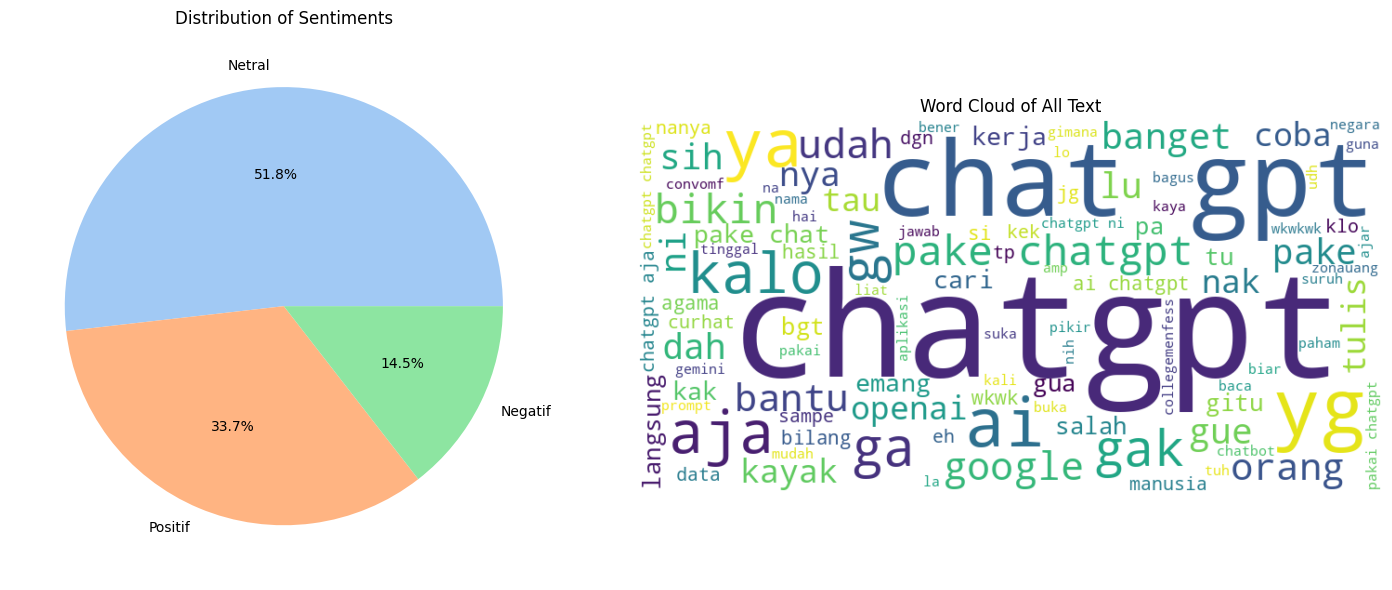

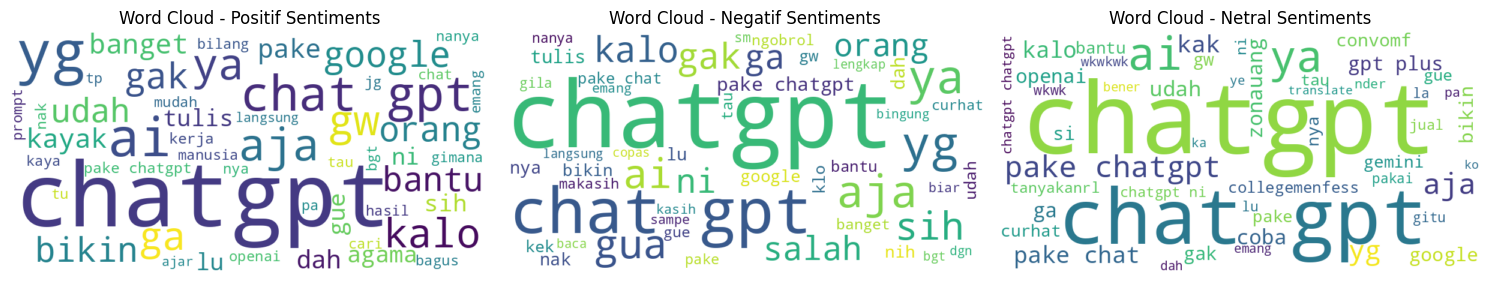


Sentiment Distribution:
naive_bayes_prediction
Netral     1531
Positif     996
Negatif     428
Name: count, dtype: int64

Percentage Distribution:
naive_bayes_prediction
Netral     51.81
Positif    33.71
Negatif    14.48
Name: count, dtype: float64 %


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# Read the results
df = pd.read_csv('hasil_sentimen_naive_bayes_optimized.csv')

# Create figure with subplots
plt.figure(figsize=(15, 6))

# 1. Pie Chart for Sentiment Distribution
plt.subplot(1, 2, 1)
sentiment_counts = df['naive_bayes_prediction'].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title('Distribution of Sentiments')

# 2. Word Cloud for each sentiment
plt.subplot(1, 2, 2)
text_data = " ".join(df['text'])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(text_data)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Text')

# Adjust layout and save
plt.tight_layout()
plt.savefig('sentiment_analysis_visualization.png')
plt.show()

# Create separate wordclouds for each sentiment
plt.figure(figsize=(15, 5))
for i, sentiment in enumerate(['Positif', 'Negatif', 'Netral'], 1):
    plt.subplot(1, 3, i)
    text_data = " ".join(df[df['naive_bayes_prediction'] == sentiment]['text'])
    if text_data.strip():  # Check if there's any text
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            max_words=50
        ).generate(text_data)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud - {sentiment} Sentiments')

plt.tight_layout()
plt.savefig('sentiment_specific_wordclouds.png')
plt.show()

# Print summary statistics
print("\nSentiment Distribution:")
print(sentiment_counts)
print("\nPercentage Distribution:")
print((sentiment_counts/len(df)*100).round(2), "%")
